# Baseline Posterior Inference: Burgers Equation

- PDE: $\partial_t u + u \partial_x u = \frac{0.1}{\pi} \partial_{xx} u$
- Unknown: initial condition $a(x) = u(x, t=0)$
- Latent dimension: $d = 16$

In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "test_idx": t}
    for s, t in itertools.product([42, 123, 7], [0, 1, 2])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
from pathlib import Path

import numpyro

from src.problems.burgers import Burgers, mollifier_burgers
from src.evaluation.metrics import rmse
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, nll_score,
    plot_calibration, plot_posterior_predictive, plot_trace, plot_metrics_table,
    plot_burgers_field_comparison, plot_burgers_posterior_gallery,
    compute_per_chain_metrics, format_significance_table,
    compute_sigma_from_map, recommended_nuts_config, mcmc_reliability_flag,
    chi2_ppc,
    compute_metric_convergence, plot_metric_convergence,
    compute_prior_predictive, build_prior_result,
    plot_burgers_std_comparison,
    compute_error_std_correlation,
    load_problem, get_nf_mode, make_log_prior,
    make_gaussian_log_likelihood, make_numpyro_model,
    run_map_estimation, tune_sigma, decode_initial_condition_burgers,
    sample_unconditional_prior, decode_posterior_batched,
    run_mcmc, extract_mcmc_diagnostics,
    compute_standard_metrics, compute_bootstrap_ci_block,
    build_mcmc_result, save_experiment_result,
    print_per_chain_table, print_dimension_diagnostics, print_cross_seed_summary,
)

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
CHECKPOINT_PATH = Path("../runs/final_burgers/weights/best.pt")
TEST_DATA_PATH = "../data/burgers/viscid_test_in.mat"

problem = Burgers(seed=42, test_data_path=TEST_DATA_PATH)
params = load_problem(problem, CHECKPOINT_PATH)
beta_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

print(f"Latent dim: {problem.BETA_SIZE}")
print(f"n_mesh: {problem.n_mesh}, n_time: {problem.n_time}")
print(f"x_mesh: [{problem.x_mesh[0]:.3f}, {problem.x_mesh[-1]:.3f}]")
print(f"t_mesh: [{problem.t_mesh[0]:.3f}, {problem.t_mesh[-1]:.3f}]")

Loading data...


  Test: a=(200, 128, 1), u=(200, 12928, 1)
Setting up grids and test functions...


  int_grid: (10, 1), v: (10, 1)
Building models...


  Initialized enc: 25,808 params


  Initialized u: 103,006 params


  Initialized nf: 60,480 params
Loading checkpoint: ../runs/final_burgers/weights/best.pt
  Loaded enc
  Loaded u
  Loaded nf


Latent dim: 16
n_mesh: 128, n_time: 101
x_mesh: [-1.000, 1.000]
t_mesh: [0.000, 1.000]


## 2. Prepare Observations

In [4]:
TEST_IDX = 0
if _task_id is not None:
    TEST_IDX = PARAMETER_GRID[_task_id]["test_idx"]
N_OBS = 100

n_points = problem.get_n_points()

## 3. Inversion Config

In [5]:
inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=50.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=25, gamma=0.8),
)

## 4. Per-Seed Loop


SEED = 42


x_obs: (1, 100, 2), u_obs: (1, 100, 1)
a_true shape: (1, 128, 1), range: [-0.504, 0.504]


u_obs range: [-0.397, 0.401]


Prior predictive: a_err=1.0232, CRPS=0.1396, cov95=0.6797, CI_width=0.6128, mean_std=0.1538


  Inversion grid: n_mesh_or_grid=7, n_grid=7


...

MCMC warmup: 301.1s, sampling: 117.5s

                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      0.13      0.01      0.13      0.11      0.14   6384.78      1.00
   beta[1]      0.06      0.02      0.06      0.03      0.10   6929.65      1.00
   beta[2]     -0.04      0.01     -0.04     -0.06     -0.02   4665.51      1.00
   beta[3]     -0.16      0.01     -0.16     -0.18     -0.14   6284.04      1.00
   beta[4]      0.15      0.01      0.15      0.14      0.16   8350.16      1.00
   beta[5]      0.02      0.01      0.02     -0.00      0.04   6986.08      1.00
   beta[6]     -0.16      0.02     -0.16     -0.19     -0.12   7558.83      1.00
   beta[7]      0.27      0.01      0.27      0.26      0.29   6248.15      1.00
   beta[8]     -0.22      0.02     -0.22     -0.25     -0.19   4171.48      1.00
   beta[9]      0.17      0.01      0.17      0.15      0.18   6193.03      1.00
  beta[10]      0.09      0.01      0.09      0.07      0.11   5659.29

a_pred_all: (8000, 128), u_pred_all: (8000, 12928)



  Burgers — RQ1 Metrics
  MAP RMSE (a)                  : 0.090599
  Posterior Mean RMSE (a)       : 0.072741
  MAP RMSE (u)                  : 0.018770
  Posterior Mean RMSE (u)       : 0.017410
  CRPS (a)                      : 0.009672
  CRPS (u)                      : 0.001049
  Mean 95% CI Width (a)         : 0.069193
  Sharpness (mean std a)        : 0.017680
  sigma                         : 0.010000

Calibration (on a):
  Nominal 10% -> Empirical 10.16%
  Nominal 19% -> Empirical 24.22%
  Nominal 29% -> Empirical 31.25%
  Nominal 38% -> Empirical 37.50%
  Nominal 48% -> Empirical 43.75%
  Nominal 57% -> Empirical 56.25%
  Nominal 67% -> Empirical 65.62%
  Nominal 76% -> Empirical 75.78%
  Nominal 86% -> Empirical 85.16%
  Nominal 95% -> Empirical 92.19%


──────────────────────────────────────────────────────────────────────────────────
  RQ1 — Bootstrap CI on Posterior Metrics (Burgers)
──────────────────────────────────────────────────────────────────────────────────
  CRPS (a)                                   0.00967  95% CI [0.00960, 0.00974]
  Coverage 95% (a)                           0.92188  95% CI [0.92188, 0.93750]
  CI Width 95% (a)                           0.06919  95% CI [0.06881, 0.06961]
  Sharpness (a)                              0.01768  95% CI [0.01758, 0.01778]
──────────────────────────────────────────────────────────────────────────────────
  Significance: ** p<0.01  * p<0.05  ~ p<0.1  n.s. not significant
  Bootstrap CIs reflect MCMC finite-sample variability, not posterior uncertainty.
──────────────────────────────────────────────────────────────────────────────────

Per-chain consistency:
  Chain      CRPS     Cov95      CI W     Sharp
      1  0.00954  0.9375  0.06911  0.01776
      2  0.00963  0.9219  0.068

Saved structured result to: /workspace/experiments/results/structured/baseline/burgers_2026-06-12T06-00-37_seed42_test1.json


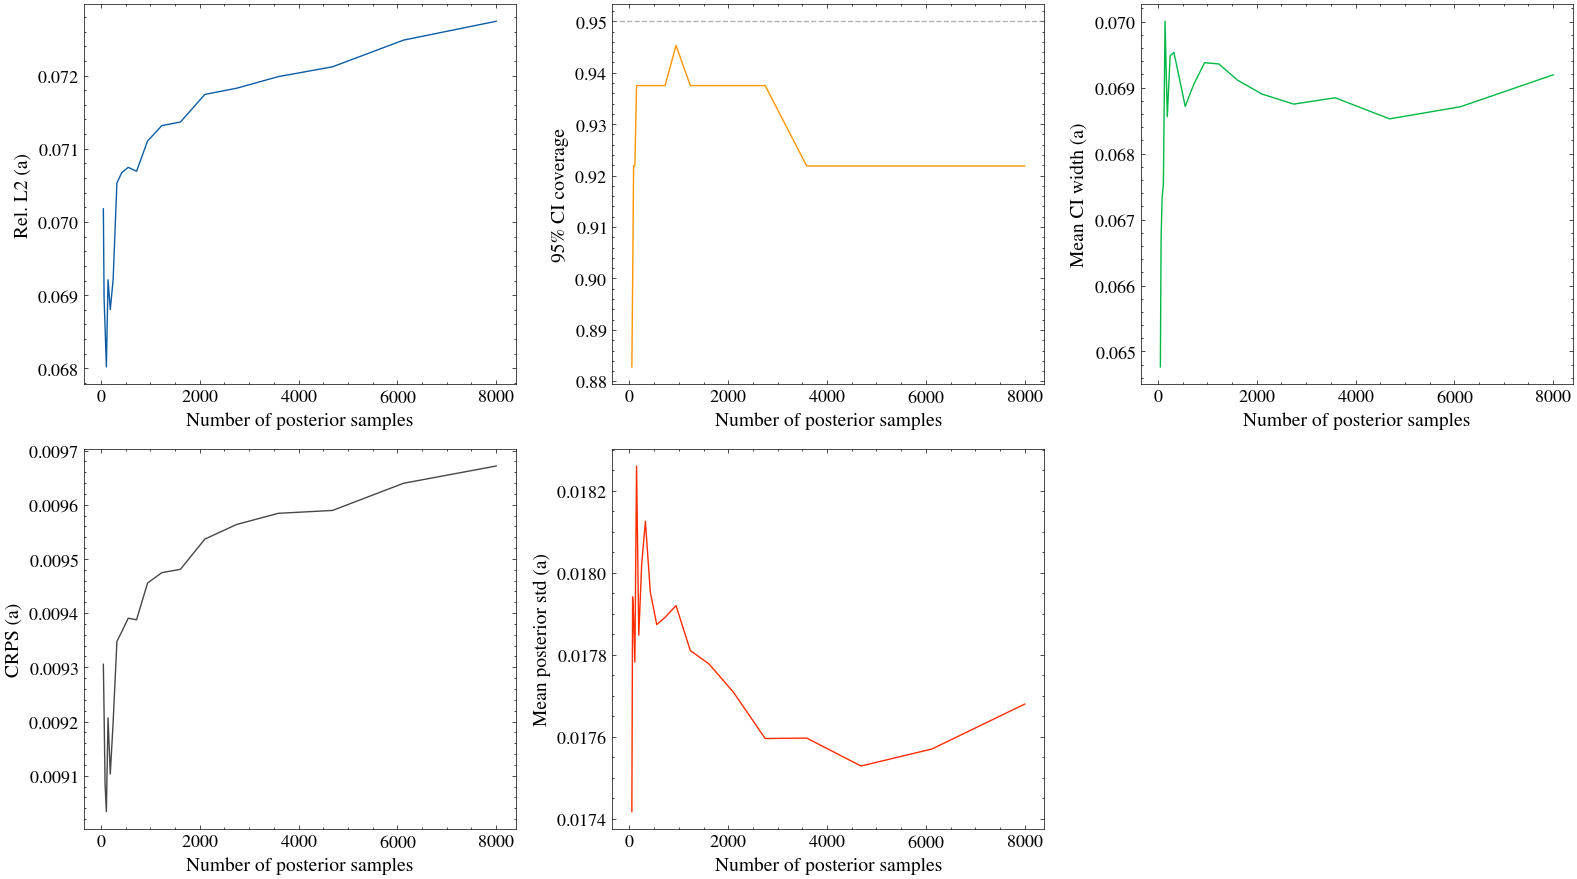

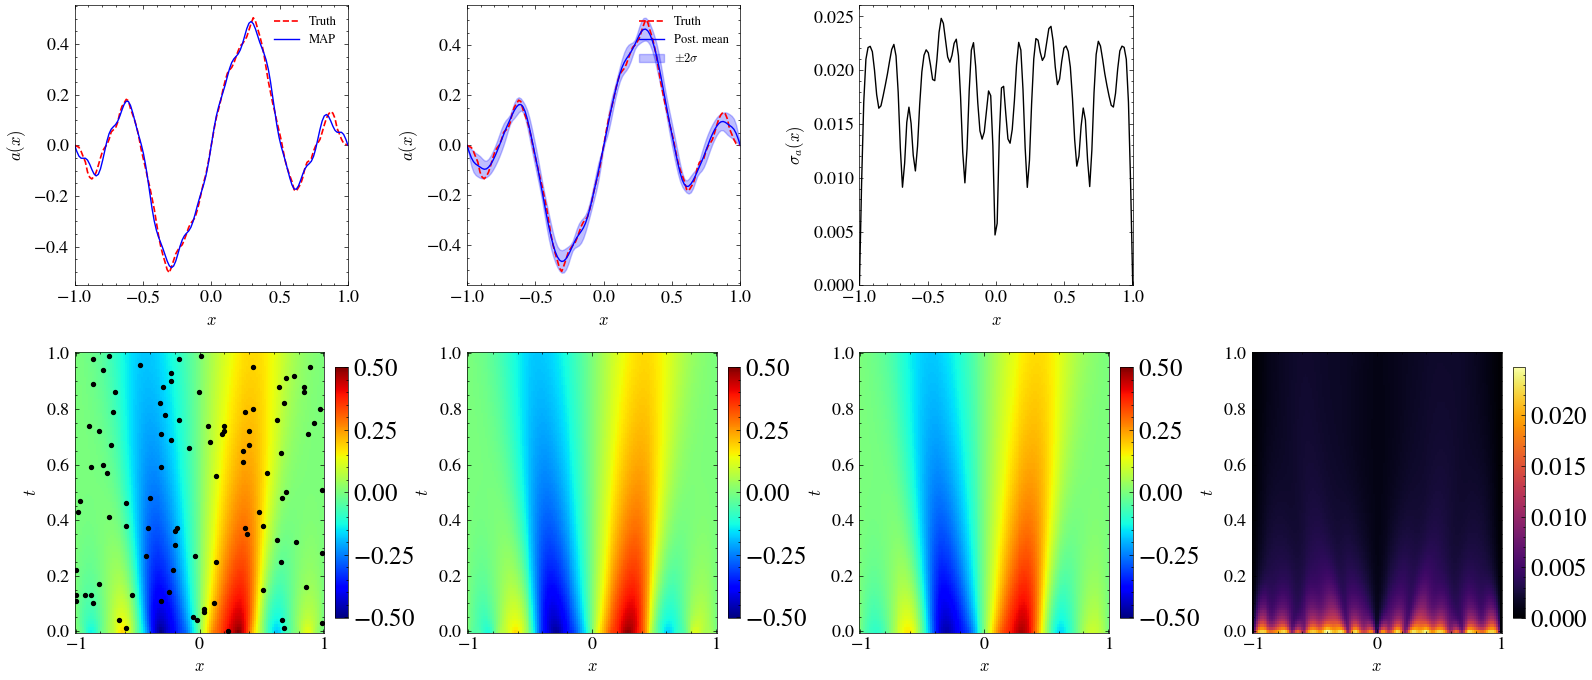

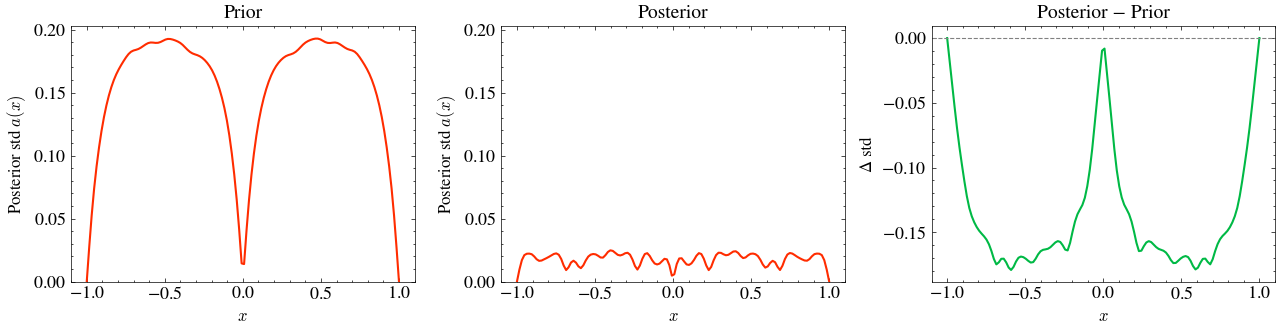

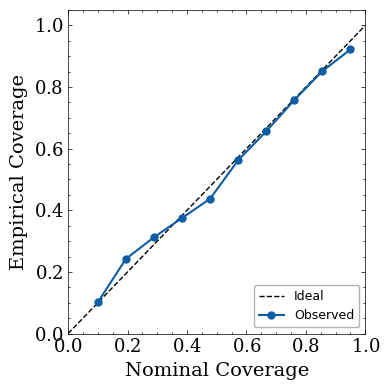

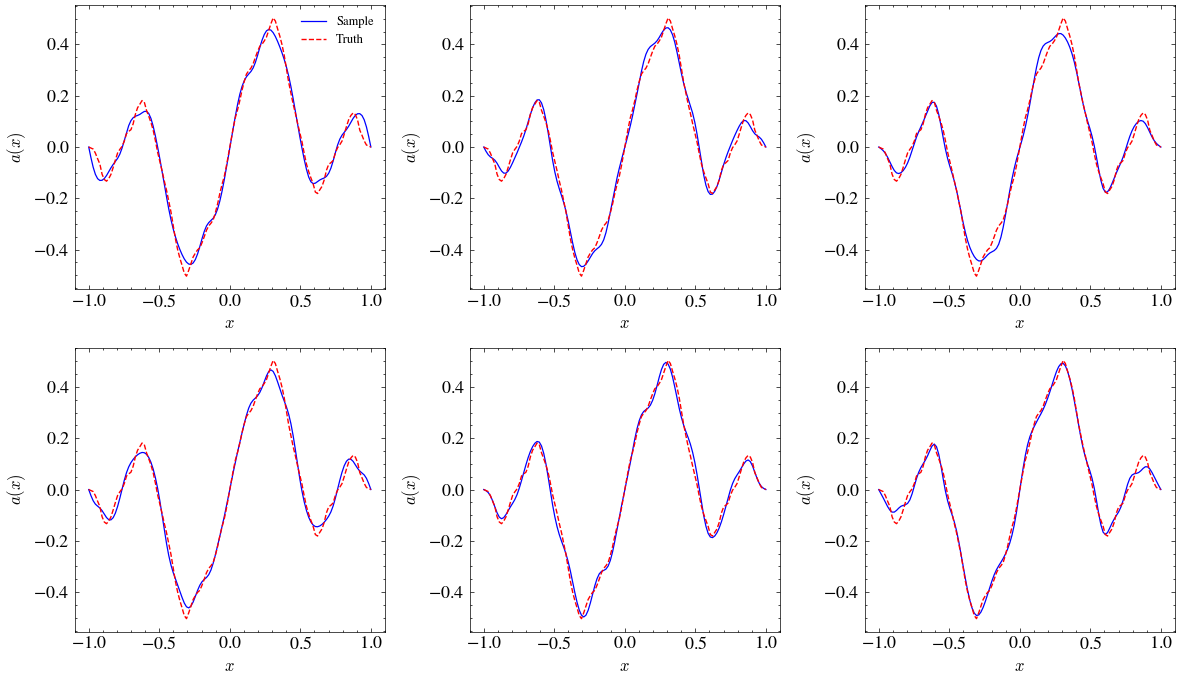

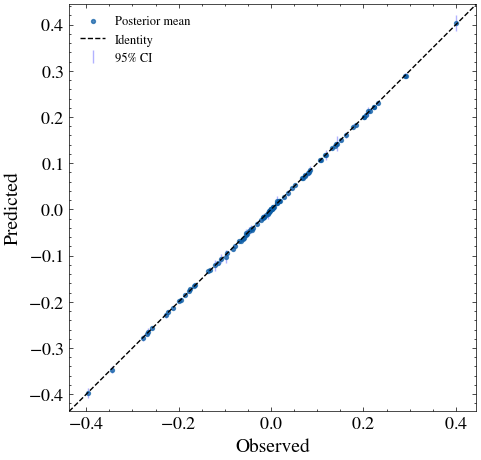

  Chi2 PPC: chi2=2.44, p=1.0000 (df=100)
Spearman rho(|error|, std) = 0.193, p = 2.92e-02
Per-dimension diagnostics:
 dim       ESS     R-hat        mean         std
   0    6384.8    1.0000      0.1277      0.0088
   1    6929.6    0.9999      0.0616      0.0212
   2    4665.5    1.0006     -0.0427      0.0125
   3    6284.0    0.9999     -0.1609      0.0134
   4    8350.2    0.9999      0.1493      0.0081
   5    6986.1    1.0000      0.0171      0.0129
   6    7558.8    0.9997     -0.1553      0.0191
   7    6248.2    0.9999      0.2709      0.0092
   8    4171.5    1.0015     -0.2188      0.0162
   9    6193.0    1.0000      0.1666      0.0105
  10    5659.3    1.0003      0.0911      0.0118
  11    4583.2    1.0006      0.1994      0.0132
  12    6227.0    1.0001      0.1445      0.0129
  13    6768.8    0.9998      0.0002      0.0198
  14    8007.2    0.9999     -0.0093      0.0166
  15    5997.9    1.0004     -0.0257      0.0195

Divergences: 0 / 8000 (0.0%)

  RELIABILITY: [PAS

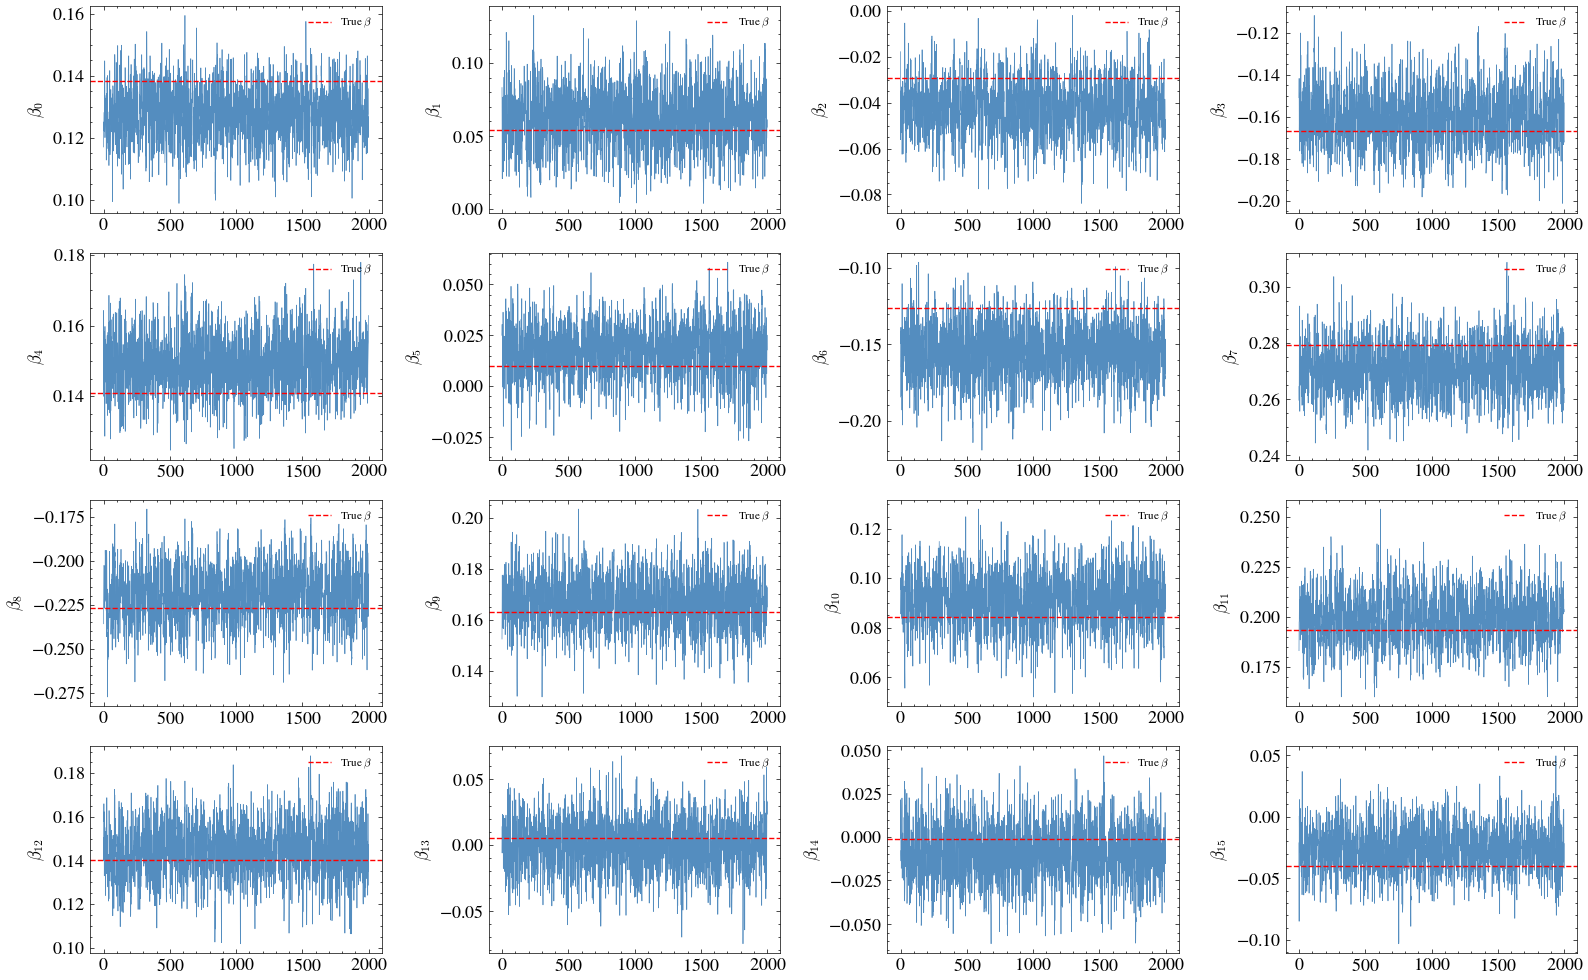

In [6]:
NUM_WARMUP    = 5000
NUM_SAMPLES   = 2000
NUM_CHAINS    = 4
CHAIN_METHOD  = 'vectorized'

for SEED in SEEDS:
    print(f"\n{'='*60}")
    print(f"SEED = {SEED}")
    print(f"{'='*60}")

    _t_total_start = time.time()

    FIGURE_DIR = Path(f'figures/baseline_burgers/seed{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    # ### Observations (this seed)

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    obs_indices = problem.sample_observation_indices(n_points, N_OBS, 'random', key)

    obs_data = problem.prepare_observations(
        sample_indices=[TEST_IDX],
        obs_indices=obs_indices,
    )

    x_full = obs_data['x_full']
    x_obs  = obs_data['x_obs']
    u_obs  = obs_data['u_obs']
    a_true = obs_data['a_true']
    u_true = obs_data['u_true']

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]

    print(f"x_obs: {x_obs.shape}, u_obs: {u_obs.shape}")
    print(f"a_true shape: {a_true.shape}, range: [{float(a_true.min()):.3f}, {float(a_true.max()):.3f}]")
    print(f"u_obs range: [{float(u_obs.min()):.3f}, {float(u_obs.max()):.3f}]")

    # ### Prior Predictive Baseline

    a_true_np = np.array(a_true[0, :, 0])
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
    )
    prior_a_std = np.std(prior_a_samples, axis=0)
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}, "
          f"CI_width={prior_metrics['ci_width']:.4f}, mean_std={prior_metrics['mean_std']:.4f}")

    # ### Log-likelihood and NumPyro model

    log_likelihood_fn = make_gaussian_log_likelihood(problem, params, mollifier_burgers, x_obs, u_obs)
    numpyro_model = make_numpyro_model(d, log_prior_fn, log_likelihood_fn)

    # ### MAP Baseline

    map_result = run_map_estimation(problem, params, x_obs, u_obs, x_full, inv_config, rng)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    u_map = map_result['u_map']
    _map_time_s = map_result['time_s']
    rng = map_result['rng']

    rmse_map_a = rmse(a_map, a_true[0])
    rmse_map_u = rmse(u_map, u_true[0])
    print(f"\nMAP RMSE: a={rmse_map_a:.6f}, u={rmse_map_u:.6f}")

    from src.utils.PlotFigure import Plot
    h = map_result['loss_history']
    Plot.show_loss(
        [h['total'], h['weighted_pde'], h['weighted_data']],
        ['Total', f'PDE (x{inv_config.loss_weights.pde})', f'Data (x{inv_config.loss_weights.data})'],
        save_path=str(FIGURE_DIR / 'map_loss_curves.png'),
    )

    # ### Full MCMC Run

    SIGMA_CANDIDATES = [0.001, 0.002, 0.003, 0.005, 0.007, 0.01]

    def _model_factory(sigma):
        def _model():
            numpyro_model(sigma=sigma)
        return _model

    def _decode_fn(beta_samples):
        return decode_initial_condition_burgers(problem, params, mollifier_burgers, beta_samples)

    _tune_nuts_cfg = recommended_nuts_config(d, sigma=0.005)
    rng, tune_key = jax.random.split(rng)
    SIGMA, _ = tune_sigma(
        model_fn_factory=_model_factory,
        beta_mode=beta_mode,
        sigma_candidates=SIGMA_CANDIDATES,
        rng_key=tune_key,
        decode_fn=_decode_fn,
        a_true=np.array(a_true[0, :, 0]),
        target_accept_prob=_tune_nuts_cfg['target_accept_prob'],
    )
    print(f"sigma (tuned): {SIGMA:.6f}")

    print(f"Running NUTS: {NUM_WARMUP} warmup, {NUM_SAMPLES} samples, {NUM_CHAINS} chains ({CHAIN_METHOD}), sigma={SIGMA}")

    nuts_cfg = recommended_nuts_config(d, SIGMA)
    rng, mcmc_key = random.split(rng)
    mcmc, timing = run_mcmc(
        numpyro_model, {"beta": beta_mode}, {"sigma": SIGMA}, mcmc_key,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )

    mcmc.print_summary()

    diag = extract_mcmc_diagnostics(mcmc, sample_name="beta", total_samples=NUM_CHAINS * NUM_SAMPLES)
    beta_samples = diag['samples']

    # ### Decode Posterior Samples

    a_pred_all, u_pred_all = decode_posterior_batched(problem, params, beta_samples, x_full)

    a_mean = np.mean(a_pred_all, axis=0)
    a_std  = np.std(a_pred_all,  axis=0)
    u_mean = np.mean(u_pred_all, axis=0)
    u_std  = np.std(u_pred_all,  axis=0)

    print(f"a_pred_all: {a_pred_all.shape}, u_pred_all: {u_pred_all.shape}")

    # ### Metrics

    a_true_np    = np.array(a_true[0, :, 0])
    a_mean_np    = a_mean
    a_map_np     = np.array(a_map[:, 0])
    a_samples_np = a_pred_all

    u_true_np    = np.array(u_true[0, :, 0])
    u_mean_np    = u_mean
    u_map_np     = np.array(u_map[:, 0])
    u_samples_np = u_pred_all

    rmse_post_a = rmse(jnp.array(a_mean_np), jnp.array(a_true_np))
    rmse_post_u = rmse(jnp.array(u_mean_np), jnp.array(u_true_np))

    crps_a = float(np.mean(crps_ensemble(a_samples_np, a_true_np)))
    crps_u = float(np.mean(crps_ensemble(u_samples_np, u_true_np)))

    nll_a = nll_score(a_samples_np, a_true_np)

    cal_levels, cal_empirical = compute_calibration(a_samples_np, a_true_np)

    ci_w      = ci_width_95(a_samples_np)
    sharpness = float(np.mean(a_std))

    plot_metrics_table({
        'MAP RMSE (a)':              float(rmse_map_a),
        'Posterior Mean RMSE (a)':   float(rmse_post_a),
        'MAP RMSE (u)':              float(rmse_map_u),
        'Posterior Mean RMSE (u)':   float(rmse_post_u),
        'CRPS (a)':                  crps_a,
        'CRPS (u)':                  crps_u,
        'Mean 95% CI Width (a)':     ci_w,
        'Sharpness (mean std a)':    sharpness,
        'sigma':                     SIGMA,
    }, title='Burgers — RQ1 Metrics')

    print("Calibration (on a):")
    for nom, emp in zip(cal_levels, cal_empirical):
        print(f"  Nominal {nom:.0%} -> Empirical {emp:.2%}")

    # ### Statistical Confidence in Metrics

    bs_results = compute_bootstrap_ci_block(a_samples_np, a_true_np)
    format_significance_table({
        'CRPS (a)':         bs_results['crps_a'],
        'Coverage 95% (a)': bs_results['coverage_95'],
        'CI Width 95% (a)': bs_results['ci_width'],
        'Sharpness (a)':    bs_results['sharpness'],
    }, title='RQ1 — Bootstrap CI on Posterior Metrics (Burgers)')

    chain_metrics = compute_per_chain_metrics(a_samples_np, a_true_np, NUM_CHAINS)
    print_per_chain_table(chain_metrics, NUM_CHAINS)

    # ### Metric Convergence

    conv_result = compute_metric_convergence(a_samples_np, a_true_np)

    from results_schema import ExperimentResult
    from datetime import datetime

    u_pred_at_obs = u_samples_np[:, np.array(obs_indices)]
    u_obs_np      = np.array(u_obs[0, :, 0])
    chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, SIGMA)

    spearman_rho, spearman_p = compute_error_std_correlation(
        a_true_np, a_mean_np, a_std,
        save_path=None,
    )

    run_result = {
        "sigma": SIGMA,
        "ess_min": diag['ess_min'],
        "rhat_max": diag['rhat_max'],
        "rhat_mean": diag['rhat_mean'],
        "n_div": diag['n_div'],
        "reliability_flag": diag['flag'],
        "reliability_explanation": diag['flag_explanation'],
        "a_err": float(rmse_post_a),
        "u_err": float(rmse_post_u),
        "crps_a": crps_a,
        "nll_a": nll_a,
        "chi2_ppc": chi2_stat,
        "chi2_ppc_pvalue": chi2_pval,
        "coverage_95": float(cal_empirical[-1]),
        "ci_width": float(ci_w),
        "mean_std": sharpness,
        "cal_levels": cal_levels,
        "cal_empirical": cal_empirical,
        "map_a_err": float(rmse_map_a),
        "map_u_err": float(rmse_map_u),
        "spearman_rho_error_std": spearman_rho,
        "spearman_pvalue_error_std": spearman_p,
        "warmup_time_s": timing['warmup_time_s'],
        "sampling_time_s": timing['sampling_time_s'],
        "step_time_s": timing['step_time_s'],
    }

    mcmc_result = build_mcmc_result(run_result, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS)

    experiment = ExperimentResult(
        experiment="baseline",
        problem="burgers",
        experiment_type="single",
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        seed=SEED,
        test_idx=TEST_IDX,
        condition=mcmc_result,
        prior=build_prior_result(prior_metrics),
        laplace=None,
        map_time_s=_map_time_s,
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    plot_metric_convergence(
        [conv_result],
        save_path=FIGURE_DIR / 'metric_convergence.png',
    )

    # ### Plots

    x_mesh_np = np.array(problem.x_mesh)
    t_mesh_np = np.array(problem.t_mesh)

    plot_burgers_field_comparison(
        x_mesh_np, t_mesh_np,
        a_true_np, a_map_np, a_mean_np, a_std,
        u_true_np, u_map_np, u_mean_np, u_std,
        obs_coords=np.array(x_obs[0]),
        save_path=FIGURE_DIR / 'field_comparison.png',
    )

    plot_burgers_std_comparison(
        x_mesh_np, prior_a_std, a_std,
        label_a='Prior', label_b='Posterior',
        save_path=FIGURE_DIR / 'prior_posterior_std.png',
    )

    plot_calibration(cal_levels, cal_empirical, save_path=FIGURE_DIR / 'calibration.png')

    plot_burgers_posterior_gallery(
        x_mesh_np, a_samples_np, a_true=a_true_np, n_show=6,
        save_path=FIGURE_DIR / 'posterior_gallery.png',
    )

    u_pred_at_obs = u_samples_np[:, np.array(obs_indices)]
    u_obs_np      = np.array(u_obs[0, :, 0])
    plot_posterior_predictive(
        u_obs_np, u_pred_at_obs,
        obs_label='u observed',
        save_path=FIGURE_DIR / 'posterior_predictive.png',
    )

    chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, SIGMA)
    print(f"  Chi2 PPC: chi2={chi2_stat:.2f}, p={chi2_pval:.4f} (df={u_obs_np.shape[0]})")

    # ### Spatial Error-Uncertainty Correlation

    spearman_rho, spearman_p = compute_error_std_correlation(
        a_true_np, a_mean_np, a_std,
        save_path=FIGURE_DIR / 'error_vs_std.png',
    )
    print(f'Spearman rho(|error|, std) = {spearman_rho:.3f}, p = {spearman_p:.2e}')

    # ### MCMC Diagnostics (Appendix)

    print_dimension_diagnostics(np.array(beta_samples), diag['ess'], diag['rhat'])

    extra_fields = mcmc.get_extra_fields()
    if "diverging" in extra_fields:
        n_div = int(extra_fields["diverging"].sum())
        total = NUM_CHAINS * NUM_SAMPLES
        print(f"\nDivergences: {n_div} / {total} ({n_div/total:.1%})")
    else:
        print("\nDivergence info not available")

    print(f"\n  RELIABILITY: [{diag['flag']}] {diag['flag_explanation']}")

    beta_true_np    = np.array(beta_true)
    beta_all_chains = np.array(mcmc.get_samples(group_by_chain=True)["beta"])
    beta_for_trace  = beta_all_chains[0]
    plot_trace(beta_for_trace, beta_true_np, num_warmup=0, save_path=FIGURE_DIR / 'trace_plots.png')

## Cross-Seed Aggregation Summary

In [7]:
print_cross_seed_summary("baseline", "burgers")

Cross-Seed Summary (10 seeds: [7, 7, 7, 42, 42, 42, 42, 123, 123, 123])

Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.1216      0.0581      0.0727      0.2306
u_err                 0.0276      0.0102      0.0174      0.0495
crps_a                0.0092      0.0020      0.0059      0.0118
coverage_95           0.9430      0.0463      0.8828      0.9922
ci_width              0.0716      0.0056      0.0647      0.0809
mean_std              0.0183      0.0014      0.0165      0.0207
ess_min            4468.0748    992.0975   3126.4232   6125.3348
rhat_max              1.0013      0.0008      1.0006      1.0030
n_div                 0.0000      0.0000      0.0000      0.0000
